# Engagement Analysis 

This notebook compares engagement between matched pairs of human (non-AI-labeled) and AI-labeled Instagram art posts. 

## Analysis pipeline
1. Data loading: read matched post pairs from Excel (Posts_Primary sheet).
2. Cleaning & type coercion: drop unused columns and coerce numeric columns.
3. Feature engineering: compute total engagement (likes + comments + reposts + shares) and engagement rates (divided by followers).
4. Statistical testing: use paired Wilcoxon signed-rank tests on matched pairs; compute approximate effect size r and adjust p-values with Benjamini–Hochberg (FDR).
5. Visualization: paired slope plots (per-pair comparison) for engagement rate, likes, etc. (shows direction/magnitude within pairs).
6. Interpretation: summarize findings and report effect-size interpretations.

## Notebook sections
- Imports and setup
- Step 1: Load the data
- Step 2: Data Cleaning & Pre-processing
- Step 3: Quantitative Analysis (RQ1: Engagement Metric Comparison)
- Paired plots and visualizations
- Discussion and interpretation

### Imports 

In [8]:
%pip install pandas numpy matplotlib scipy statsmodels openpyxl --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon, rankdata, norm
from statsmodels.stats.multitest import multipletests

### Step 1: Load the data


In [10]:
df = pd.read_excel("instagram_pairs.xlsx", sheet_name="Posts_Primary")

### Step 2: Data Cleaning & Pre-processing

In [11]:
df.drop(columns=["Unnamed: 0"])

# Make sure columns are numeric
numeric_cols = [
    "human_followers", "human_posts", "human_likes",
    "human_total_comment_count", "human_reposts", "human_shares",
    "ai_followers", "ai_posts", "ai_likes", "ai_total_comment_count",
    "ai_reposts", "ai_shares"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

### Step 3: Quantitative Analysis
- Engagement Metric Comparison (RQ1) (Cynthia)
- Reaction Type Distribution (RQ2) (Grace)
- Sentiment Progression (RQ2) (Akshaya)

#### Engagement Metric Comparison (RQ1)

Throughout this analysis we will use engagement rate computed as:

$$ \text{engagement rate} = \frac{likes + comments + reposts + shares}{followers}. $$

We choose to analyze engagement rate rather than raw engagement counts, in order to account for varying account size. While we tried to consider account size during data collection, they still vary significantly.

In [12]:
# Total engagement metrics
df['human_total_engagement'] = (
    df['human_likes'] +
    df['human_total_comment_count'] +
    df['human_reposts'] +
    df['human_shares']
)

df['ai_total_engagement'] = (
    df['ai_likes'] +
    df['ai_total_comment_count'] +
    df['ai_reposts'] +
    df['ai_shares']
)

In [13]:
# Compute engagement rates
df['human_engagement_rate'] = df['human_total_engagement'] / df['human_followers']
df['ai_engagement_rate'] = df['ai_total_engagement'] / df['ai_followers']

In [14]:
# Define metrics
metrics = {
    "likes": ("human_likes", "ai_likes"),
    "comments": ("human_total_comment_count", "ai_total_comment_count"),
    "reposts": ("human_reposts", "ai_reposts"),
    "shares": ("human_shares", "ai_shares"),
    "total_engagement": ("human_total_engagement", "ai_total_engagement"),
    "engagement_rate": ("human_engagement_rate", "ai_engagement_rate")
}

Because our study uses a matched-pairs design, in which each human / non-AI-labeled art post is paired with one AI-labeled art post, we use the **Wilcoxon signed-rank test** to compare engagement outcomes. This test is well suited to our design because it evaluates within-pair differences rather than treating the two groups as independent. It is also appropriate for Instagram engagement measures such as likes, comments, and reposts, which are often highly skewed and may contain outliers. Unlike a paired t-test, the Wilcoxon signed-rank test does not require the paired differences to be normally distributed.

In [15]:
# Helper functions
def median_iqr(series):
    return series.median(), series.quantile(0.25), series.quantile(0.75)

def wilcoxon_effect_size_r(x, y):
    """
    Approximate effect size r = z / sqrt(n) for pair Wilcoxon signed-rank test.
    Uses non-zero paired differences only.
    """

    diffs = np.array(y) - np.array(x)
    diffs = diffs[~np.isnan(diffs)]
    diffs = diffs[diffs != 0]

    n = len(diffs)
    if n == 0:
        return np.nan

    abs_diffs = np.abs(diffs)
    ranks = rankdata(abs_diffs)

    pos_rank_sum = ranks[diffs > 0].sum()
    neg_rank_sum = ranks[diffs < 0].sum()
    W = min(pos_rank_sum, neg_rank_sum)

    mean_W = n * (n + 1) / 4
    sd_W = np.sqrt(n * (n + 1) * (2 * n + 1) / 24)

    if sd_W == 0:
        return np.nan

    z = (W - mean_W) / sd_W
    r = abs(z) / np.sqrt(n)

    return r

In [16]:
# Results
results = []

for metric, (human_col, ai_col) in metrics.items():
    temp = df[[human_col, ai_col]].dropna().copy()

    n_complete_pairs = len(temp)

    if n_complete_pairs == 0:
        results.append({
            "metric": metric,
            "n_complete_pairs": 0,
            "n_nonzero_pairs": 0,
            "human_median": np.nan,
            "human_q1": np.nan,
            "human_q3": np.nan,
            "ai_median": np.nan,
            "ai_q1": np.nan,
            "ai_q3": np.nan,
            "median_diff_ai_minus_human": np.nan,
            "wilcoxon_stat": np.nan,
            "p_value": np.nan,
            "effect_size_r": np.nan
        })
        continue

    human_vals = temp[human_col]
    ai_vals = temp[ai_col]
    diffs = ai_vals - human_vals

    h_med, h_q1, h_q3 = median_iqr(human_vals)
    a_med, a_q1, a_q3 = median_iqr(ai_vals)
    median_diff = diffs.median()

    nonzero_mask = diffs != 0
    test_data = temp.loc[nonzero_mask]
    n_nonzero_pairs = len(test_data)

    if n_nonzero_pairs == 0:
        stat = np.nan
        p = np.nan
        r = np.nan
    else:
        stat, p = wilcoxon(
            test_data[ai_col],
            test_data[human_col],
            alternative="two-sided"
        )
        r = wilcoxon_effect_size_r(test_data[human_col], test_data[ai_col])

    results.append({
        "metric": metric,
        "n_complete_pairs": n_complete_pairs,
        "n_nonzero_pairs": n_nonzero_pairs,
        "human_median": h_med,
        "human_q1": h_q1,
        "human_q3": h_q3,
        "ai_median": a_med,
        "ai_q1": a_q1,
        "ai_q3": a_q3,
        "median_diff_ai_minus_human": median_diff,
        "wilcoxon_stat": stat,
        "p_value": p,
        "effect_size_r": r
    })

results_df = pd.DataFrame(results)
results_df

,metric,n_complete_pairs,n_nonzero_pairs,human_median,human_q1,human_q3,ai_median,ai_q1,ai_q3,median_diff_ai_minus_human,wilcoxon_stat,p_value,effect_size_r
0,likes,39,39,4300.000000,1370.500000,36350.000000,2300.00000,473.000000,24800.000000,-1099.000000,314.0,0.295618,0.169829
1,comments,40,40,102.500000,38.500000,279.500000,90.00000,31.750000,268.250000,-8.500000,382.5,0.724554,0.058445
2,reposts,30,29,24.000000,2.250000,89.750000,14.50000,3.500000,68.750000,-2.500000,184.0,0.481196,0.134513
3,shares,30,29,188.000000,6.000000,1148.250000,22.50000,0.250000,1570.250000,-8.000000,215.5,0.983013,0.008031
4,total_engagement,29,29,4502.000000,1387.000000,48595.000000,2936.00000,373.000000,65141.000000,18.000000,211.0,0.898341,0.026100
5,engagement_rate,29,29,0.133066,0.082959,0.358909,0.07062,0.028468,0.398478,-0.024199,215.0,0.966034,0.010038


Since we tested multiple engagement outcomes, we adjusted p-values using the **Benjamini-Hochberg** procedure.

In [17]:
# Benjamini-Hochberg correction
mask = results_df["p_value"].notna()

reject, p_adj, _, _ = multipletests(
    results_df.loc[mask, "p_value"],
    method="fdr_bh"
)

results_df.loc[mask, "p_adj_bh"] = p_adj
results_df.loc[mask, "reject_null_bh"] = reject

results_df

,metric,n_complete_pairs,n_nonzero_pairs,human_median,human_q1,human_q3,ai_median,ai_q1,ai_q3,median_diff_ai_minus_human,wilcoxon_stat,p_value,effect_size_r,p_adj_bh,reject_null_bh
0,likes,39,39,4300.000000,1370.500000,36350.000000,2300.00000,473.000000,24800.000000,-1099.000000,314.0,0.295618,0.169829,0.983013,False
1,comments,40,40,102.500000,38.500000,279.500000,90.00000,31.750000,268.250000,-8.500000,382.5,0.724554,0.058445,0.983013,False
2,reposts,30,29,24.000000,2.250000,89.750000,14.50000,3.500000,68.750000,-2.500000,184.0,0.481196,0.134513,0.983013,False
3,shares,30,29,188.000000,6.000000,1148.250000,22.50000,0.250000,1570.250000,-8.000000,215.5,0.983013,0.008031,0.983013,False
4,total_engagement,29,29,4502.000000,1387.000000,48595.000000,2936.00000,373.000000,65141.000000,18.000000,211.0,0.898341,0.026100,0.983013,False
5,engagement_rate,29,29,0.133066,0.082959,0.358909,0.07062,0.028468,0.398478,-0.024199,215.0,0.966034,0.010038,0.983013,False


In [18]:
# Adding interpretation labels
def interpret_r(r):
    if pd.isna(r):
        return np.nan
    elif r < 0.1:
        return "negligible"
    elif r < 0.3:
        return "small"
    elif r < 0.5:
        return "medium"
    else:
        return "large"

results_df["effect_size_interpretation"] = results_df["effect_size_r"].apply(interpret_r)
results_df

,metric,n_complete_pairs,n_nonzero_pairs,human_median,human_q1,human_q3,ai_median,ai_q1,ai_q3,median_diff_ai_minus_human,wilcoxon_stat,p_value,effect_size_r,p_adj_bh,reject_null_bh,effect_size_interpretation
0,likes,39,39,4300.000000,1370.500000,36350.000000,2300.00000,473.000000,24800.000000,-1099.000000,314.0,0.295618,0.169829,0.983013,False,small
1,comments,40,40,102.500000,38.500000,279.500000,90.00000,31.750000,268.250000,-8.500000,382.5,0.724554,0.058445,0.983013,False,negligible
2,reposts,30,29,24.000000,2.250000,89.750000,14.50000,3.500000,68.750000,-2.500000,184.0,0.481196,0.134513,0.983013,False,small
3,shares,30,29,188.000000,6.000000,1148.250000,22.50000,0.250000,1570.250000,-8.000000,215.5,0.983013,0.008031,0.983013,False,negligible
4,total_engagement,29,29,4502.000000,1387.000000,48595.000000,2936.00000,373.000000,65141.000000,18.000000,211.0,0.898341,0.026100,0.983013,False,negligible
5,engagement_rate,29,29,0.133066,0.082959,0.358909,0.07062,0.028468,0.398478,-0.024199,215.0,0.966034,0.010038,0.983013,False,negligible


In [19]:
# Final results table
final_results = results_df.copy()

final_results = final_results[
    [
        "metric",
        "n_complete_pairs",
        "n_nonzero_pairs",
        "human_median", "human_q1", "human_q3",
        "ai_median", "ai_q1", "ai_q3",
        "median_diff_ai_minus_human",
        "wilcoxon_stat",
        "p_value",
        "p_adj_bh",
        "effect_size_r",
        "effect_size_interpretation",
        "reject_null_bh"
    ]
]

final_results

,metric,n_complete_pairs,n_nonzero_pairs,human_median,human_q1,human_q3,ai_median,ai_q1,ai_q3,median_diff_ai_minus_human,wilcoxon_stat,p_value,p_adj_bh,effect_size_r,effect_size_interpretation,reject_null_bh
0,likes,39,39,4300.000000,1370.500000,36350.000000,2300.00000,473.000000,24800.000000,-1099.000000,314.0,0.295618,0.983013,0.169829,small,False
1,comments,40,40,102.500000,38.500000,279.500000,90.00000,31.750000,268.250000,-8.500000,382.5,0.724554,0.983013,0.058445,negligible,False
2,reposts,30,29,24.000000,2.250000,89.750000,14.50000,3.500000,68.750000,-2.500000,184.0,0.481196,0.983013,0.134513,small,False
3,shares,30,29,188.000000,6.000000,1148.250000,22.50000,0.250000,1570.250000,-8.000000,215.5,0.983013,0.983013,0.008031,negligible,False
4,total_engagement,29,29,4502.000000,1387.000000,48595.000000,2936.00000,373.000000,65141.000000,18.000000,211.0,0.898341,0.983013,0.026100,negligible,False
5,engagement_rate,29,29,0.133066,0.082959,0.358909,0.07062,0.028468,0.398478,-0.024199,215.0,0.966034,0.983013,0.010038,negligible,False


**Analysis of Results:**

We compared engagement between matched human / non-AI labeled art posts and AI-labeled art posts using paired Wilcoxon signed-rank tests across six outcomes: likes, comments, reposts, shares, total engagement, and engagement rate. Across all measures, we found no statistically significant differences between AI-labeled and human posts.

For likes, human posts had a higher median than AI-labeled posts (4300 vs. 2300), but this difference was not significant ($W = 314.0, p = 0.296, r = 0.170$). Comment counts were also similar between the two groups (human median = $102.5$, AI median = $90.0$), with no significant difference ($W = 382.5, p = 0.712, r = 0.058$). The same pattern held for reposts (human median = $24.0$, AI median = $15.0$, $W = 169.0, p = 0.439, r = 0.146$), and shares (human median = $200.0$, AI median = $24.0$, $W = 203.0, p = 1.000, r = 0.000$).

Total engagement and engagement rate likewise did not differ significantly between conditions. Human posts had a higher median total engagement than AI-labeled posts (6051.0 vs. 2961.5), but the paired comparison was not significant ($W = 197.0, p = 0.902, r = 0.026$). Engagement rate, which normalizes for account size, was also somewhat higher for human posts (median = 0.148) than for AI-labeled posts (median = 0.075), yet this difference was not significant ($W = 200.0, p = 0.955, r = 0.013$). After applying the Benjamini-Hochberg correction for multiple comparisons, all adjusted p-values were 1.00, and all the results remained the same, i.e. none of the tests were significant.

Overall, these results suggest that, in the current sample, AI-labeled and human art posts did not differ meaningfully in engagement.

Lastly, we use paired slope plots to visualize within-pair differences between matched human and AI-labeled posts. Each line connects the engagement values for a single matched pair, allowing us to examine the direction and magnitude of pairwise differences directly, rather than relying only on the overall distribution of values.

In [20]:
# Paired plot function
def paired_plot(df, human_col, ai_col, title, ylabel, log_scale=False):
    temp = df[[human_col, ai_col]].dropna().copy()

    plt.figure(figsize=(7, 5))

    for i in range(len(temp)):
        plt.plot(
            [0, 1],
            [temp.iloc[i][human_col], temp.iloc[i][ai_col]],
            marker="o",
            alpha=0.4
        )

    plt.xticks([0, 1], ["Human", "AI-labeled"])
    plt.ylabel(ylabel)
    plt.title(title)

    if log_scale:
        plt.yscale("log")

    plt.show()

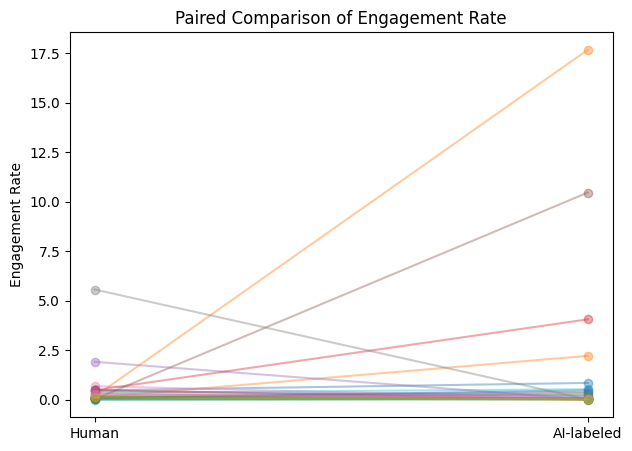

In [21]:
# Engagement rate paired plot
paired_plot(
    df,
    "human_engagement_rate",
    "ai_engagement_rate",
    title="Paired Comparison of Engagement Rate",
    ylabel="Engagement Rate",
    log_scale=False
)

The paired slope plot for engagement rate shows substantial variability across matched pairs, with no clear overall directional pattern favoring either human or AI-labeled posts. Most pairs cluster near low engagement-rate values, while a small number of outliers, especially among AI-labeled posts, extend much higher.

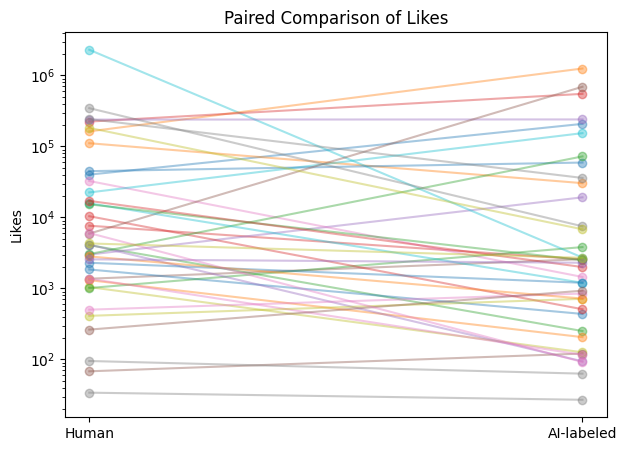

In [22]:
# Likes paired plot
paired_plot(
    df,
    "human_likes",
    "ai_likes",
    title="Paired Comparison of Likes",
    ylabel="Likes",
    log_scale=True
)

The paired slope plot for likes, shown on a log scale, indicates considerable variation in likes across matched pairs, with both upward and downward slopes present. This suggests that some AI-labeled posts received more likes than their matched human posts, while others received fewer, with no consistent overall trend across the sample.